In [47]:
import pandas as pd

df = pd.read_csv("../data/Loan_Default.csv")
print(df.head())

      ID  year loan_limit             Gender approv_in_adv loan_type  \
0  24890  2019         cf  Sex Not Available         nopre     type1   
1  24891  2019         cf               Male         nopre     type2   
2  24892  2019         cf               Male           pre     type1   
3  24893  2019         cf               Male         nopre     type1   
4  24894  2019         cf              Joint           pre     type1   

  loan_purpose Credit_Worthiness open_credit business_or_commercial  ...  \
0           p1                l1        nopc                  nob/c  ...   
1           p1                l1        nopc                    b/c  ...   
2           p1                l1        nopc                  nob/c  ...   
3           p4                l1        nopc                  nob/c  ...   
4           p1                l1        nopc                  nob/c  ...   

   credit_type  Credit_Score  co-applicant_credit_type    age  \
0          EXP           758                 

In [48]:
df.describe()

,ID,year,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,property_value,income,Credit_Score,LTV,Status,dtir1
count,148670.000000,148670.0,1.486700e+05,112231.000000,112031.000000,109028.000000,148629.000000,1.335720e+05,139520.000000,148670.000000,133572.000000,148670.000000,124549.000000
mean,99224.500000,2019.0,3.311177e+05,4.045476,0.441656,3224.996127,335.136582,4.978935e+05,6957.338876,699.789103,72.746457,0.246445,37.732932
std,42917.476598,0.0,1.839093e+05,0.561391,0.513043,3251.121510,58.409084,3.599353e+05,6496.586382,115.875857,39.967603,0.430942,10.545435
min,24890.000000,2019.0,1.650000e+04,0.000000,-3.638000,0.000000,96.000000,8.000000e+03,0.000000,500.000000,0.967478,0.000000,5.000000
25%,62057.250000,2019.0,1.965000e+05,3.625000,0.076000,581.490000,360.000000,2.680000e+05,3720.000000,599.000000,60.474860,0.000000,31.000000
50%,99224.500000,2019.0,2.965000e+05,3.990000,0.390400,2596.450000,360.000000,4.180000e+05,5760.000000,699.000000,75.135870,0.000000,39.000000
75%,136391.750000,2019.0,4.365000e+05,4.375000,0.775400,4812.500000,360.000000,6.280000e+05,8520.000000,800.000000,86.184211,0.000000,45.000000
max,173559.000000,2019.0,3.576500e+06,8.000000,3.357000,60000.000000,360.000000,1.650800e+07,578580.000000,900.000000,7831.250000,1.000000,61.000000


In [49]:
df = df.dropna(axis=1)
df.isnull().sum()

ID                          0
year                        0
Gender                      0
loan_type                   0
Credit_Worthiness           0
open_credit                 0
business_or_commercial      0
loan_amount                 0
interest_only               0
lump_sum_payment            0
construction_type           0
occupancy_type              0
Secured_by                  0
total_units                 0
credit_type                 0
Credit_Score                0
co-applicant_credit_type    0
Region                      0
Security_Type               0
Status                      0
dtype: int64

In [50]:
df['year'] = pd.to_datetime(df['year'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 148670 entries, 0 to 148669
Data columns (total 20 columns):
 #   Column                    Non-Null Count   Dtype         
---  ------                    --------------   -----         
 0   ID                        148670 non-null  int64         
 1   year                      148670 non-null  datetime64[ns]
 2   Gender                    148670 non-null  object        
 3   loan_type                 148670 non-null  object        
 4   Credit_Worthiness         148670 non-null  object        
 5   open_credit               148670 non-null  object        
 6   business_or_commercial    148670 non-null  object        
 7   loan_amount               148670 non-null  int64         
 8   interest_only             148670 non-null  object        
 9   lump_sum_payment          148670 non-null  object        
 10  construction_type         148670 non-null  object        
 11  occupancy_type            148670 non-null  object        
 12  Se

<Axes: >

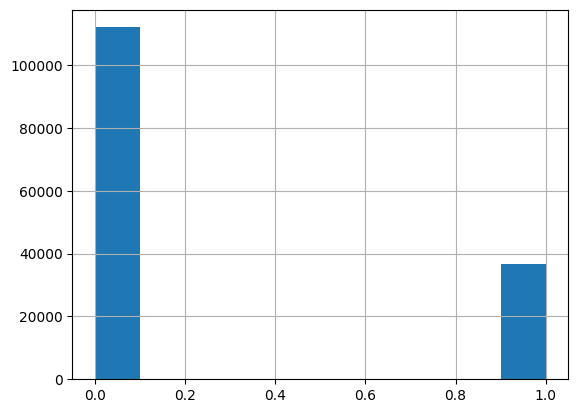

In [51]:

df['Status'].hist()

In [52]:
X = df.drop('Status', axis=1)
Y = df['Status']

In [53]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, random_state=42, stratify=Y
)

In [69]:
num_cols = [
    'loan_amount',
    'Credit_Score',
]


In [70]:
cat_cols = [
    'Gender',
    'loan_type',
    'Credit_Worthiness',
    'open_credit',
    'business_or_commercial',
    'interest_only',
    'lump_sum_payment',
    'construction_type',
    'occupancy_type',
    'Secured_by',
    'total_units',
    'credit_type',
    'co-applicant_credit_type',
    'Region',
    'Security_Type'
]


In [71]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

In [72]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

lr_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', LogisticRegression())
])

In [75]:
from sklearn.neighbors import KNeighborsClassifier

knn_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', KNeighborsClassifier())
])

In [77]:
from sklearn.tree import DecisionTreeClassifier

dc_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', DecisionTreeClassifier())
])

In [78]:
from sklearn.ensemble import RandomForestClassifier

rf_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier())
])

In [79]:
from sklearn.ensemble import GradientBoostingClassifier

gbm_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', GradientBoostingClassifier())
])

In [80]:
from sklearn.svm import SVC

svc_pipeline = Pipeline([
    ('prep', preprocessor),
    ('model', SVC())
])

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

models = {
    "Logistic": lr_pipeline,
    "KNN": knn_pipeline,
    "Decision Tree": dc_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Booster Classifier": gbm_pipeline,
    "SVC": svc_pipeline,
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:,1]

    print(name)
    print(classification_report(y_test, preds))
    print("ROC-AUC:", roc_auc_score(y_test, probs))


Logistic
              precision    recall  f1-score   support

           0       0.85      0.99      0.92     22406
           1       0.97      0.47      0.63      7328

    accuracy                           0.87     29734
   macro avg       0.91      0.73      0.78     29734
weighted avg       0.88      0.87      0.85     29734

ROC-AUC: 0.7988600550061256
KNN
              precision    recall  f1-score   support

           0       0.85      0.96      0.91     22406
           1       0.82      0.49      0.61      7328

    accuracy                           0.85     29734
   macro avg       0.84      0.73      0.76     29734
weighted avg       0.84      0.85      0.83     29734

ROC-AUC: 0.7578436039872742
Decision Tree
              precision    recall  f1-score   support

           0       0.85      0.84      0.85     22406
           1       0.53      0.56      0.55      7328

    accuracy                           0.77     29734
   macro avg       0.69      0.70      0.70  